# SE ResNet18 Architecture

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator

## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


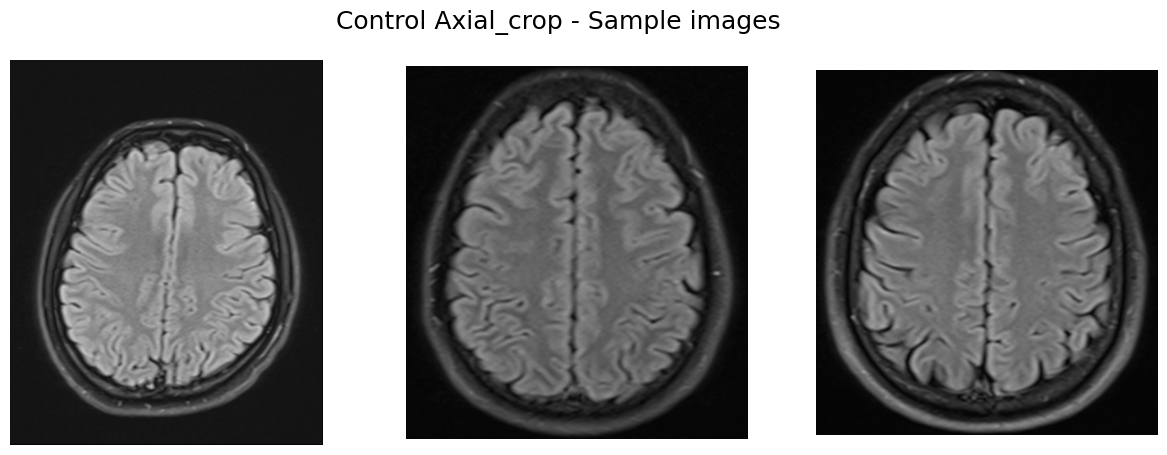

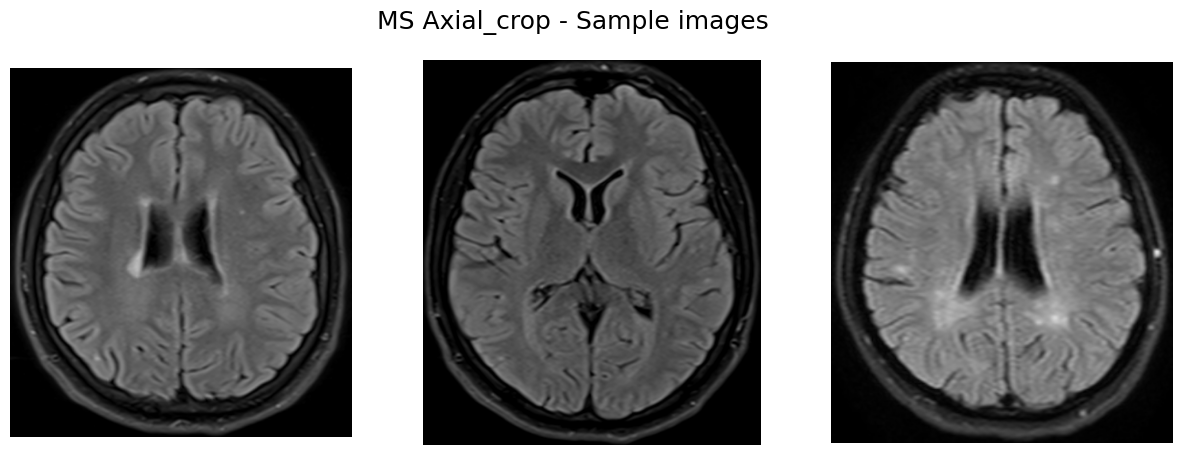

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Training samples: 1321, Testing samples: 331


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, test_loader, test_data = data.get_data_loaders(image_paths, labels, train_transform, test_transform)

## Model Instantiation

There are several different SE model variations relating to different SE placement options. These options are as follows:
- **architecture = "se_end"** : Single SE before the classifier (after layer 4)
- **architecture = "se_block_pre"**: SE built into each BasicBlock (before the shortcut)

In [4]:
# Using simplest SE model variation with a single SE module at the end of ResNet18 before classification
model = models.get_model(architecture="se_block_pre")

get_model()>>> 
 SEResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlockSEPre(
        (block): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (se): SEBlock(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in

## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [5]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head",          # train only classifier head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,                    # lower LR for fine-tuning
        "parameters": "all",           # train backbone + head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}

[base] Epoch 1/10 - Loss: 0.5205 - Acc: 0.7449
[base] Epoch 2/10 - Loss: 0.4057 - Acc: 0.8191
[base] Epoch 3/10 - Loss: 0.3775 - Acc: 0.8251
[base] Epoch 4/10 - Loss: 0.3433 - Acc: 0.8486
[base] Epoch 5/10 - Loss: 0.3620 - Acc: 0.8213
[base] Epoch 6/10 - Loss: 0.3182 - Acc: 0.8584
[base] Epoch 7/10 - Loss: 0.3061 - Acc: 0.8577
[base] Epoch 8/10 - Loss: 0.3007 - Acc: 0.8690
[base] Epoch 9/10 - Loss: 0.2813 - Acc: 0.8804
[base] Epoch 10/10 - Loss: 0.2851 - Acc: 0.8728


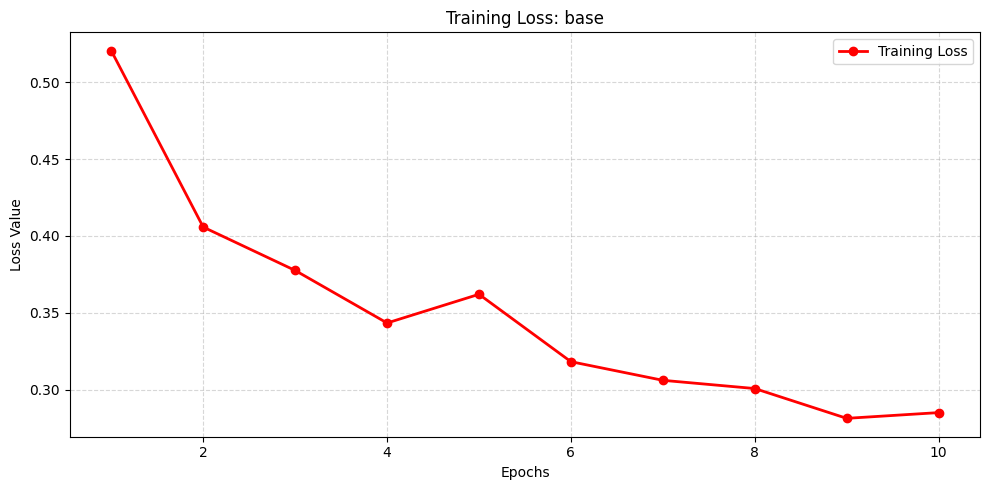

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\se_pre_base.pth


In [6]:
# Base training phase - only training classifier head
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="base", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="base")

trainer.save_weights(model, WEIGHTS_DIR / "se_pre_base.pth")

[fine_tune] Epoch 1/5 - Loss: 0.2739 - Acc: 0.8842
[fine_tune] Epoch 2/5 - Loss: 0.2331 - Acc: 0.9054
[fine_tune] Epoch 3/5 - Loss: 0.1859 - Acc: 0.9304
[fine_tune] Epoch 4/5 - Loss: 0.1550 - Acc: 0.9463
[fine_tune] Epoch 5/5 - Loss: 0.1613 - Acc: 0.9394


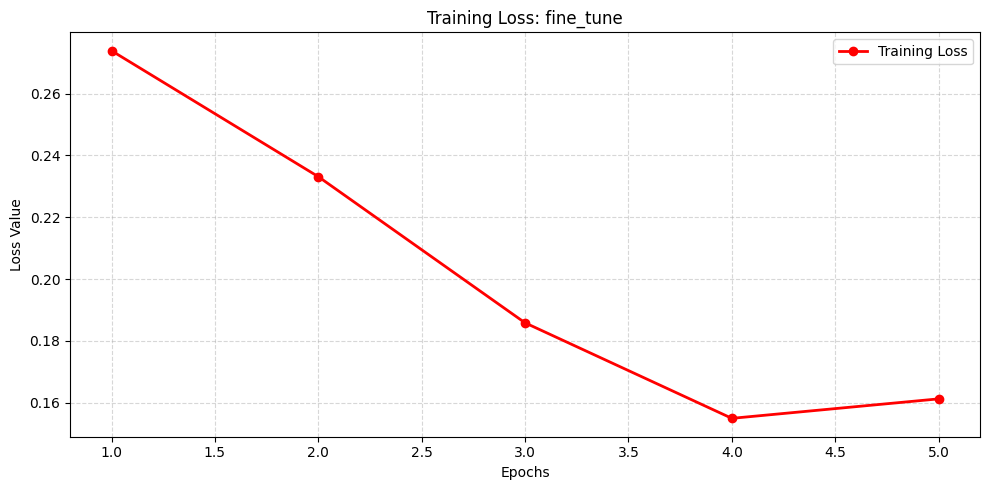

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\se_pre_fine.pth


In [7]:
# Fine-tuning phase - training entire model
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="fine_tune", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="fine_tune")

trainer.save_weights(model, WEIGHTS_DIR / "se_pre_fine.pth")

## Load Saved Weights
Option to load weights from previous training

In [8]:
model = models.get_model(architecture="se_block_pre")
model = trainer.load_weights(model, WEIGHTS_DIR / "se_pre_fine.pth")

get_model()>>> 
 SEResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlockSEPre(
        (block): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (se): SEBlock(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in

## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [9]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\refactor\src\evaluator.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.9003021148036254
Precision: 0.907563025210084
Recall: 0.8307692307692308
Confusion Matrix:
 [[190  11]
 [ 22 108]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       201
           1       0.91      0.83      0.87       130

    accuracy                           0.90       331
   macro avg       0.90      0.89      0.89       331
weighted avg       0.90      0.90      0.90       331



## Model Prediction Visualisation

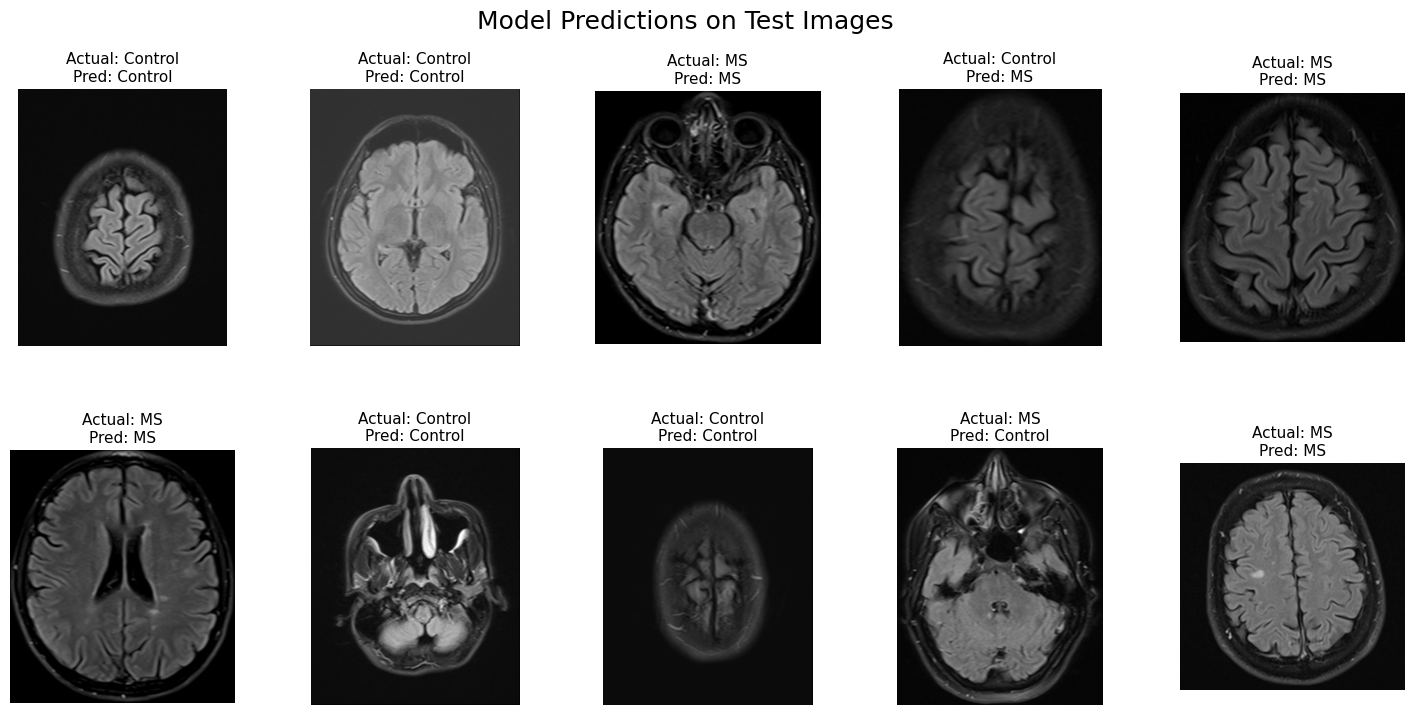

In [10]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)